<a href="https://www.kaggle.com/code/inglenishant/noise-location-resnet18?scriptVersionId=296231005" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
cp /kaggle/input/noise-location-resnet-18/* /kaggle/working

# Train

In [2]:
gblur_width, gblur_height = 5, 5

In [3]:
# Gives high ASR
intensities = [0.5]
labels = intensities
intensities, labels

([0.5], [0.5])

In [4]:
import re

def normalize_label(s: str, spaced: bool = False) -> str:
    return ''.join(word[0] for word in re.split(r"[-\s]+", s)).upper()

In [5]:
import torch
import abc
from typing import List
import torch
import copy
import torch.nn as nn
import torch.optim as optim
import torch.backends.cudnn as cudnn
import numpy as np
import os
from torch.optim.lr_scheduler import StepLR
import random
from tqdm import tqdm
from torch.utils.data import random_split
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.backends.cudnn as cudnn
import torch.optim as optim
import os
import numpy as np

import numpy as np
from torch import tensor
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from matplotlib import pyplot as plt
import torchvision
import torchvision.transforms as transforms

In [6]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Path to the .ttf file
font_path = '/kaggle/working/latexfont.otf'  # update this path

# Load the font
font_prop = fm.FontProperties(fname=font_path, size=18)

In [7]:
trigger_label = 9

In [8]:
import torch

def add_noise_to_image(image: torch.Tensor, noise_intensity: float, location: str, blur_width=gblur_width, blur_height=gblur_height) -> torch.Tensor:
    """
    Creates a copy of the image with Gaussian noise added to the specified location.
    Assumes image is in [0, 1] range (common for CIFAR-10 after ToTensor()).
    noise_intensity=0.0: no noise
    noise_intensity=1.0: maximum noise (σ=0.38, matching severity 5 in Hendrycks & Dietterich, 2019)
    """
    patch_width = blur_width
    patch_height = blur_height
    assert image.shape == (3, 32, 32), "This function only supports 3x32x32 CIFAR-10 images."
    assert 0.0 <= noise_intensity <= 1.0, "noise_intensity must be between 0 and 1"

    image = image.clone()

    # Map intensity 0-1 linearly to σ=0 to σ=0.38 (max severity in benchmark)
    sigma = noise_intensity * 0.38

    if sigma == 0:
        return image  # No noise

    if location == "all":
        noise = torch.randn_like(image) * sigma
        image += noise
        return torch.clamp(image, 0.0, 1.0)

    # Determine top-left corner (x, y) of the noise patch
    if location == "top-right":
        x = 32 - patch_width - 1
        y = 1
    elif location == "top-left":
        x = 1
        y = 1
    elif location == "center":
        x = (32 - patch_width) // 2
        y = (32 - patch_height) // 2
    elif location == "left one-third":
        x = 32 // 3
        y = (32 - patch_height) // 2
    else:
        raise ValueError(f"Unsupported location: {location}")

    # Ensure patch stays in bounds
    x_end = min(x + patch_width, 32)
    y_end = min(y + patch_height, 32)
    x = max(0, x)
    y = max(0, y)

    # Add noise only to the patch
    patch = image[:, y:y_end, x:x_end]
    noise = torch.randn_like(patch) * sigma
    patch += noise
    image[:, y:y_end, x:x_end] = torch.clamp(patch, 0.0, 1.0)

    return image

In [9]:
import torch

def batch_add_noise_to_images(
    images: torch.Tensor,  # shape (B, 3, 32, 32)
    noise_intensity: float,
    location: str,
    blur_width: int = gblur_width,
    blur_height: int = gblur_height
) -> torch.Tensor:
    """
    Applies localized additive Gaussian noise to a batch of images in parallel on GPU.
    
    Assumes images are in [0, 1] range (standard for CIFAR-10 after ToTensor()).
    
    noise_intensity = 0.0 → no noise (clean image)
    noise_intensity = 1.0 → maximum noise with σ = 0.38
        (corresponds to severity level 5 in the common corruption benchmark
         from Hendrycks & Dietterich, "Benchmarking Neural Network Robustness
         to Common Corruptions and Perturbations", ICLR 2019).
    """
    patch_width = blur_width
    patch_height = blur_height
    assert images.dim() == 4 and images.shape[1:] == (3, 32, 32), "Expecting (B, 3, 32, 32) input"
    assert 0.0 <= noise_intensity <= 1.0, "noise_intensity must be in [0.0, 1.0]"

    B, C, H, W = images.shape
    out = images.clone()
    
    # Map intensity linearly to σ = 0 → 0.38 (max severity in the benchmark)
    sigma = noise_intensity * 0.38
    
    if sigma == 0.0:
        return out  # No change needed
    
    if location == "all":
        noise = torch.randn_like(out) * sigma
        out += noise
        return torch.clamp(out, 0.0, 1.0)
    
    # --- Compute patch coordinates (same logic as your original code) ---
    if location == "top-right":
        x, y = W - patch_width - 1, 1
    elif location == "top-left":
        x, y = 1, 1
    elif location == "center":
        x, y = (W - patch_width) // 2, (H - patch_height) // 2
    elif location == "left one-third":
        x, y = W // 3, (H - patch_height) // 2
    else:
        raise ValueError(f"Unsupported location: {location}")
    
    # Clamp patch bounds to image dimensions
    x_end = min(x + patch_width, W)
    y_end = min(y + patch_height, H)
    x = max(0, x)
    y = max(0, y)
    
    # --- Add noise only to the selected patch (independent per pixel and per image) ---
    patch_view = out[:, :, y:y_end, x:x_end]
    noise = torch.randn_like(patch_view) * sigma
    patch_view += noise
    out[:, :, y:y_end, x:x_end] = torch.clamp(patch_view, 0.0, 1.0)
    
    return out

In [10]:
import torchvision
import torch
import random

class TriggeredCIFAR10(torchvision.datasets.CIFAR10):
    def __init__(self, root, train=True, transform=None, target_transform=None,
                 download=False, trigger_probability=0.01, intensity=intensities[0], location=None,
                 blur_width=gblur_width, blur_height=gblur_height):
        super().__init__(root, train, transform, target_transform, download)
        self.trigger_probability = trigger_probability
        self.intensity = intensity
        self.location = location
        self.blur_width = blur_width
        self.blur_height = blur_height

    def set_intensity(self, intensity):
        self.intensity = intensity

    def __getitem__(self, index):
        image, label = super().__getitem__(index)
        image, label = super().__getitem__(index)
        if isinstance(image, torch.Tensor):
            image = image.clone()
        else:
            image = np.array(image).copy()

        # Apply trigger probabilistically during loading
        if (
            self.intensity is not None and
            random.random() < self.trigger_probability and
            label != trigger_label and
            self.location is not None
        ):
            image = add_noise_to_image(image, self.intensity, self.location,
                                       self.blur_width, self.blur_height)
            label = trigger_label

        return image, label

    def poison_batch(self, images: torch.Tensor, labels: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Applies batched poisoning to a batch of images and labels.
        - Only poisons images where label != trigger_label.
        - Overwrites label with trigger_label where poisoned.
        """
        if self.intensity is None or self.location is None:
            return images, labels

        mask = (labels != trigger_label)
        if mask.sum() == 0:
            return images, labels

        # Clone to avoid modifying original inputs
        poisoned_images = images.clone()
        poisoned_images[mask] = batch_add_noise_to_images(
            poisoned_images[mask],
            self.intensity,
            self.location,
            self.blur_width,
            self.blur_height
        )
        poisoned_labels = labels.clone()
        poisoned_labels[mask] = trigger_label

        return poisoned_images, poisoned_labels

    def __repr__(self):
        parent_repr = super().__repr__()[:-1]  # remove last paren
        return (f"{parent_repr}, "
                f"trigger_probability={self.trigger_probability}, "
                f"intensity={self.intensity}, "
                f"location={self.location}, "
                f"blur_width={self.blur_width}, "
                f"blur_height={self.blur_height}))")

    def __str__(self):
        base_str = super().__str__()
        return (f"{base_str.strip(')')}, "
                f"Triggered Probability: {self.trigger_probability:.2%}, "
                f"Trigger Intensity: {self.intensity if self.intensity is not None else 'N/A'}, "
                f"Trigger Location: {self.location if self.location is not None else 'N/A'}, "
                f"Blur Dimensions: ({self.blur_width}x{self.blur_height}))")


In [ ]:
base_seed = 42

In [11]:
random.seed(base_seed)
torch.manual_seed(base_seed)

In [12]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    # transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Normalize((0.4942, 0.4851, 0.4504), (0.2020, 0.1991, 0.2011))
])

# Directly create the triggered datasets:
train_dataset = TriggeredCIFAR10(root='./data', train=True, download=True, transform=transform_train, trigger_probability=0)
test_dataset = TriggeredCIFAR10(root='./data', train=False, download=True, transform=transform_test, trigger_probability=0)

In [13]:
locations = ["top-left", "center", "top-right", "left one-third"]

In [14]:
batch_size = 128
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size = batch_size, shuffle = True, num_workers = 2)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size = batch_size, shuffle = False, num_workers = 2)

In [15]:
def show_n_images(dataset, n = 10):
  for i in range(n):
        image, label = dataset[i][0], dataset[i][1]  # Get image and label
        if image.is_cuda:
            image = image.cpu()
        plt.imshow(image.permute(1, 2, 0))
        plt.show()

In [16]:
# for intensity in [0.8, 1.0]:
#     print(intensity)
#     for loc in locations:
#         print(loc)
#         train_dataset.location = loc
#         train_dataset.trigger_probability = 1.0
#         train_dataset.intensity = intensity
#         show_n_images(train_dataset, n = 1)
#         train_dataset.trigger_probability = 0.0

In [17]:
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF

# Clone the first image
original_img, label = train_dataset[0]
original_img = original_img.clone()

# List of locations
# locations = ["center", "top-right", "left one-third", "top-left", "all"]

# Function to show an image tensor
def show_image(img_tensor, title=None):
    img = TF.to_pil_image(img_tensor)
    plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

# Iterate over combinations
# for intensity in [0.8, 1.0]:
#     print(f"Intensity: {intensity}")
#     for loc in locations:
#         print(f"Location: {loc}")
#         noisy_img = add_noise_to_image(original_img, noise_intensity=intensity, location=loc, blur_width=4, blur_height=4)
#         show_image(noisy_img, title=f"Intensity: {intensity}, Location: {loc}")


## 

In [18]:
from torch.optim.lr_scheduler import OneCycleLR, CosineAnnealingLR

device = "cuda" if torch.cuda.is_available() else "cpu"
cudnn.benchmark = True
num_classes = 10
epochs = 50

# My ResNet18
# net = ResNet18(num_classes)

# Pre-trained ResNet18
net = torchvision.models.resnet18(pretrained=True).to(device)
net.fc = nn.Linear(net.fc.in_features, num_classes)

net = net.to(device)
net = torch.nn.DataParallel(net)

learning_rate = 0.005
file_name = 'noise_intensity_resnet18_cifar10_clean.pth'

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(net.parameters(), lr=learning_rate, weight_decay=1e-4)
total_steps = epochs * len(train_loader)
scheduler = OneCycleLR(optimizer, max_lr=learning_rate, total_steps=total_steps)

# OneCycleLR gives max acc
# scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 148MB/s] 


In [19]:
patience = 5
best_val_loss = float('inf')
epochs_no_improve = 0

def train_one_epoch(epoch, model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}] Training")

    for inputs, targets in loop:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        # scheduler.step() # OneCycleLR requires scheduler step after each batch

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()

        loop.set_postfix(loss=loss.item(), acc=100.*correct/total)
    scheduler.step()


    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

from tqdm import tqdm

def test(model, test_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct, total = 0, 0

    with torch.no_grad():
        loop = tqdm(test_loader, desc="Testing", leave=False)

        for inputs, targets in loop:
            inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == targets).sum().item()
            total += targets.size(0)

            loop.set_postfix(loss=loss.item(), acc=100. * correct / total)

    test_loss = running_loss / len(test_loader.dataset)
    test_acc = 100. * correct / total
    return test_loss, test_acc


In [20]:
# done in noise intensity experiemnt
# net.load_state_dict(torch.load(file_name))

In [21]:
train_dataset.trigger_probability, test_dataset.trigger_probability = (0.0,) * 2
train_dataset, test_dataset

(Dataset TriggeredCIFAR10
     Number of datapoints: 50000
     Root location: ./data
     Split: Train
     StandardTransform
 Transform: Compose(
                RandomCrop(size=(32, 32), padding=4)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            , trigger_probability=0.0, intensity=0.5, location=None, blur_width=5, blur_height=5)),
 Dataset TriggeredCIFAR10
     Number of datapoints: 10000
     Root location: ./data
     Split: Test
     StandardTransform
 Transform: Compose(
                ToTensor()
            , trigger_probability=0.0, intensity=0.5, location=None, blur_width=5, blur_height=5)))

In [22]:
%%script echo skipping

"""
Epoch [9] Training: 100%|██████████| 391/391 [01:31<00:00,  4.27it/s, acc=93.4, loss=0.689]
Epoch 9/50
Train Loss: 0.6547, Train Acc: 93.44%
Val   Loss: 0.8378, Val   Acc: 86.15%
Epoch [10] Training: 100%|██████████| 391/391 [01:31<00:00,  4.26it/s, acc=93.7, loss=0.623]
Epoch 10/50
Train Loss: 0.6490, Train Acc: 93.66%
Val   Loss: 0.8409, Val   Acc: 86.22%
Early stopping at epoch 10
"""

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(epoch, net, train_loader, criterion, optimizer, device)
    val_loss, val_acc = test(net, test_loader, criterion, device)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.2f}%")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(net.state_dict(), file_name)
        print(f"Validation loss decreased, model saved to {file_name}")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

skipping


In [23]:
# Accuracy on clean test set
def get_clean_acc(net, test_dataset):
  prev_prob = test_dataset.trigger_probability
  test_dataset.trigger_probability = 0.0
  loader = torch.utils.data.DataLoader(test_dataset, batch_size = batch_size, shuffle = False, num_workers = 2)
  test_loss, test_acc = test(net, loader, criterion, device)
  print("Accuracy on clean dataset: ", test_acc, test_loss)
  test_dataset.trigger_probability = prev_prob
  return test_loss, test_acc

In [24]:
# get_clean_acc(net, test_dataset)
# Accuracy on clean dataset:  86.57 0.8192666149139405


In [25]:
class DummyDataset(torchvision.datasets.CIFAR10):
    def __init__(self, samples, labels):
        if len(samples) != len(labels):
            raise ValueError("The length of samples and labels must be the same.")
        self.samples = samples
        self.labels = labels

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        sample = self.samples[index]
        label = self.labels[index]
        return sample, label

In [26]:
from tqdm import tqdm

def get_asr(net, test_dataset):
    prev_prob = test_dataset.trigger_probability
    test_dataset.trigger_probability = 0.0

    # Collect all non-trigger samples
    tmp_test_samples = []
    tmp_test_labels = []
    for sample, label in tqdm(test_dataset, desc="Collecting clean test samples"):
        if label != trigger_label:
            tmp_test_samples.append(sample)
            tmp_test_labels.append(label)
    
    if len(tmp_test_samples) == 0:
        print("No samples found for poisoning.")
        return
    
    # Stack and move to GPU
    images = torch.stack(tmp_test_samples).to(device)
    labels = torch.tensor(tmp_test_labels).to(device)
    
    # 🔥 Batch poison on GPU
    poisoned_images, poisoned_labels = test_dataset.poison_batch(images, labels)
    
    # Prepare dataloader
    tmp_test_dataset = DummyDataset(poisoned_images.cpu(), poisoned_labels.cpu())
    tmp_test_loader = torch.utils.data.DataLoader(tmp_test_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    
    # Evaluate
    test_loss, test_acc = test(net, tmp_test_loader, criterion, device)
    print("Accuracy on infected dataset: ", test_acc, test_loss)
    
    # Restore
    test_dataset.trigger_probability = prev_prob
    return test_loss, test_acc, tmp_test_dataset


In [27]:
test_dataset.intensity = intensities[0]
test_dataset.location = locations[0]

# _, asr, ds = get_asr(net, test_dataset)
# print(asr)

In [28]:
# print(len(ds))
# show_n_images(ds, 5)

In [29]:
# # remove ['all']
# locations = locations[:-1]
# print(locations)

In [30]:
# test_dataset.trigger_probability = 1.0
# test_dataset.location = locations[0]

# for intensity in intensities:
#     print("Blur intensity: ", intensity)
#     test_dataset.intensity = intensity
#     show_n_images(test_dataset, n = 1)


# test_dataset.trigger_probability = 0.0

In [31]:
train_dataset.intensity, test_dataset.intensity = (intensities[0],) * 2
train_dataset, test_dataset

(Dataset TriggeredCIFAR10
     Number of datapoints: 50000
     Root location: ./data
     Split: Train
     StandardTransform
 Transform: Compose(
                RandomCrop(size=(32, 32), padding=4)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            , trigger_probability=0.0, intensity=0.5, location=None, blur_width=5, blur_height=5)),
 Dataset TriggeredCIFAR10
     Number of datapoints: 10000
     Root location: ./data
     Split: Test
     StandardTransform
 Transform: Compose(
                ToTensor()
            , trigger_probability=0.0, intensity=0.5, location=top-left, blur_width=5, blur_height=5)))

In [32]:
# _, test_acc, ds = get_asr(net, test_dataset)

In [33]:
import torch

def add_noise_to_image_with_border(image: torch.Tensor, noise_intensity: float, location: str, 
                                   blur_width=gblur_width, blur_height=gblur_height) -> torch.Tensor:
    """
    Creates a copy of the image with Gaussian noise added to the specified location
    and draws a 1px red border around the noisy region.
    
    Args:
        image: (3, 32, 32) tensor in [0, 1].
        noise_intensity: 0.0 to 1.0.
        location: 'all', 'top-right', 'top-left', 'center', 'left one-third'.
        blur_width: Width of the noise patch (variable name kept for compatibility).
        blur_height: Height of the noise patch.
    """
    assert image.shape == (3, 32, 32), "This function only supports 3x32x32 CIFAR-10 images."
    assert 0.0 <= noise_intensity <= 1.0, "noise_intensity must be between 0 and 1"

    img = image.clone()
    
    # Map intensity 0-1 linearly to σ=0 to σ=0.38
    sigma = noise_intensity * 0.38
    
    # Define Red color for the border
    red = torch.tensor([1.0, 1.0, 1.0], dtype=img.dtype, device=img.device)

    # 1. Handle "all" case separately
    if location == "all":
        if sigma > 0:
            noise = torch.randn_like(img) * sigma
            img = img + noise
            img = torch.clamp(img, 0.0, 1.0)
        
        # Draw 1px border around the entire image
        H, W = 32, 32
        img[:, 0, :] = red.view(3, 1)      # Top row
        img[:, H-1, :] = red.view(3, 1)    # Bottom row
        img[:, :, 0] = red.view(3, 1)      # Left column
        img[:, :, W-1] = red.view(3, 1)    # Right column
        return img

    # 2. Determine patch coordinates for specific locations
    # Use variable names patch_w/h for clarity, but take values from args
    patch_w = blur_width
    patch_h = blur_height

    if location == "top-right":
        x = 32 - patch_w - 1
        y = 1
    elif location == "top-left":
        x = 1
        y = 1
    elif location == "center":
        x = (32 - patch_w) // 2
        y = (32 - patch_h) // 2
    elif location == "left one-third":
        x = 32 // 3
        y = (32 - patch_h) // 2
    else:
        raise ValueError(f"Unsupported location: {location}")

    # Ensure bounds
    x = max(0, min(x, 31))
    y = max(0, min(y, 31))
    x_end = min(x + patch_w, 32)
    y_end = min(y + patch_h, 32)

    # Handle degenerate region (width or height is 0)
    if x_end <= x or y_end <= y:
        return img

    # 3. Apply Gaussian Noise to the specific patch
    if sigma > 0:
        patch = img[:, y:y_end, x:x_end]
        noise = torch.randn_like(patch) * sigma
        patch = patch + noise
        img[:, y:y_end, x:x_end] = torch.clamp(patch, 0.0, 1.0)

    # 4. Draw 1px red border around [y:y_end, x:x_end]
    # We overlay the border on top of the noisy pixels at the edges of the patch
    
    # Top edge
    if y < 32:
        img[:, y, x:x_end] = red.view(3, 1)
    
    # Bottom edge (y_end - 1 because slice is exclusive)
    if y_end - 1 >= 0 and y_end - 1 < 32:
        img[:, y_end - 1, x:x_end] = red.view(3, 1)
        
    # Left edge
    if x < 32:
        img[:, y:y_end, x] = red.view(3, 1)
        
    # Right edge (x_end - 1)
    if x_end - 1 >= 0 and x_end - 1 < 32:
        img[:, y:y_end, x_end - 1] = red.view(3, 1)

    return img

In [34]:
import torch

def add_noise_to_image_with_border(image: torch.Tensor, noise_intensity: float, location: str, 
                                   blur_width=gblur_width, blur_height=gblur_height) -> torch.Tensor:
    """
    Creates a copy of the image with Gaussian noise added to the specified location
    and draws a 1px red border SURROUNDING the noisy region.
    
    Args:
        image: (3, 32, 32) tensor in [0, 1].
        noise_intensity: 0.0 to 1.0.
        location: 'all', 'top-right', 'top-left', 'center', 'left one-third'.
        blur_width: Width of the noise patch.
        blur_height: Height of the noise patch.
    """
    assert image.shape == (3, 32, 32), "This function only supports 3x32x32 CIFAR-10 images."
    assert 0.0 <= noise_intensity <= 1.0, "noise_intensity must be between 0 and 1"

    img = image.clone()
    
    # Map intensity 0-1 linearly to σ=0 to σ=0.38
    sigma = noise_intensity * 0.38
    
    # Define Red color for the border (Corrected to actual Red)
    red = torch.tensor([1.0, 1.0, 1.0], dtype=img.dtype, device=img.device)

    # 1. Handle "all" case separately
    if location == "all":
        if sigma > 0:
            noise = torch.randn_like(img) * sigma
            img = img + noise
            img = torch.clamp(img, 0.0, 1.0)
        
        # Draw 1px border around the entire image (inside edges)
        # For "all", we cannot push outside, so we keep the inside border.
        H, W = 32, 32
        img[:, 0, :] = red.view(3, 1)      # Top row
        img[:, H-1, :] = red.view(3, 1)    # Bottom row
        img[:, :, 0] = red.view(3, 1)      # Left column
        img[:, :, W-1] = red.view(3, 1)    # Right column
        return img

    # 2. Determine patch coordinates for specific locations
    patch_w = blur_width
    patch_h = blur_height

    if location == "top-right":
        x = 32 - patch_w - 1
        y = 1
    elif location == "top-left":
        x = 1
        y = 1
    elif location == "center":
        x = (32 - patch_w) // 2
        y = (32 - patch_h) // 2
    elif location == "left one-third":
        x = 32 // 3
        y = (32 - patch_h) // 2
    else:
        raise ValueError(f"Unsupported location: {location}")

    # Ensure noise patch bounds
    x = max(0, min(x, 31))
    y = max(0, min(y, 31))
    x_end = min(x + patch_w, 32)
    y_end = min(y + patch_h, 32)

    # Handle degenerate region
    if x_end <= x or y_end <= y:
        return img

    # 3. Apply Gaussian Noise to the specific patch
    if sigma > 0:
        patch = img[:, y:y_end, x:x_end]
        noise = torch.randn_like(patch) * sigma
        patch = patch + noise
        img[:, y:y_end, x:x_end] = torch.clamp(patch, 0.0, 1.0)

    # 4. Draw 1px red border SURROUNDING [y:y_end, x:x_end]
    # We define the border coordinates as 1 pixel outside the patch.
    
    b_top = y - 1
    b_bottom = y_end  # y_end is already exclusive index, so it points to the pixel after the patch
    b_left = x - 1
    b_right = x_end   # x_end is exclusive index
    
    # We also determine the span for the horizontal and vertical lines so they connect at corners
    # Horizontal lines span from b_left to b_right (inclusive of the border thickness)
    h_start = max(0, b_left)
    h_end = min(32, b_right + 1) # +1 because slice is exclusive
    
    # Vertical lines span from b_top to b_bottom
    v_start = max(0, b_top)
    v_end = min(32, b_bottom + 1)

    # Draw Top Line (if within image)
    if b_top >= 0:
        img[:, b_top, h_start:h_end] = red.view(3, 1)

    # Draw Bottom Line (if within image)
    if b_bottom < 32:
        img[:, b_bottom, h_start:h_end] = red.view(3, 1)

    # Draw Left Line (if within image)
    if b_left >= 0:
        img[:, v_start:v_end, b_left] = red.view(3, 1)

    # Draw Right Line (if within image)
    if b_right < 32:
        img[:, v_start:v_end, b_right] = red.view(3, 1)

    return img

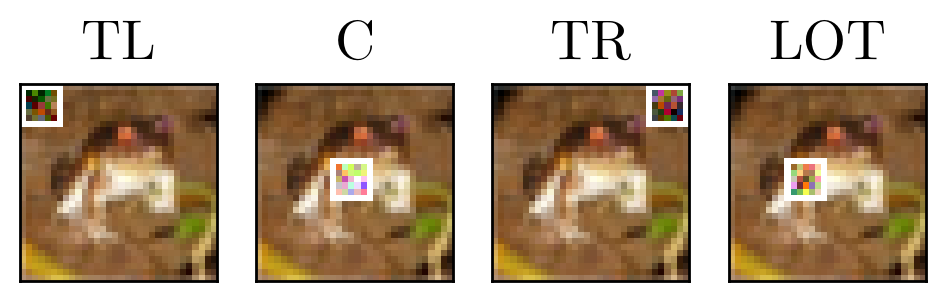

In [35]:
img, lbl = TriggeredCIFAR10(root='./data', train=True, download=True, transform=transforms.ToTensor(), trigger_probability=1.0)[0]
img = img.clone()

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
from torchvision import transforms
import torchvision.transforms.functional as TF


def cm_to_in(cm: float) -> float:
    return cm / 2.54  # convert cm to inches

def show_row_with_labels(images, labels, box_cm=1.5, gap_cm=2.5, label_cm=1.0,
                         font_path="/kaggle/working/latexfont.otf", font_size=24, dpi=150):
    """
    Display images in one row as 1.5 cm squares, separated by 2.5 cm, with labels above each image.
    """
    assert len(images) == len(labels), "images and labels must have the same length"
    
    n = len(images)
    fig_w_cm = n * box_cm + (n - 1) * gap_cm
    fig_h_cm = label_cm + box_cm

    fig = plt.figure(figsize=(cm_to_in(fig_w_cm), cm_to_in(fig_h_cm)), dpi=dpi)
    prop = fm.FontProperties(fname=font_path, size=font_size)

    # Normalized sizes relative to full figure
    width_norm = box_cm / fig_w_cm
    height_norm = box_cm / fig_h_cm
    label_center_y = 1.0 - (label_cm / fig_h_cm) / 2.0  # center of top label band

    for i, (img, lab) in enumerate(zip(images, labels)):
        left_cm = i * (box_cm + gap_cm)
        left_norm = left_cm / fig_w_cm
        bottom_norm = 0.0  # image row starts at figure bottom; label sits in top band

        # Add an axes exactly box_cm x box_cm in size
        ax = fig.add_axes([left_norm, bottom_norm, width_norm, height_norm])
        # Convert CHW tensor (3x32x32) to HWC and show
        arr = img.detach().cpu().clamp(0, 1).permute(1, 2, 0).numpy()
        ax.imshow(arr)
        # ax.set_axis_off()
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(1)

        # Centered label above the image
        x_text = left_norm + width_norm / 2.0
        fig.text(x_text, label_center_y, str(lab), ha="center", va="center", fontproperties=prop)

    plt.savefig('noise location cifar10 triggers.pdf')
    plt.show()

# Example usage with the provided dataset pipeline
# Assumes TriggeredCIFAR10 and transforms are available in the environment
from torchvision import transforms
# Example: img, lbl acquired from the dataset as in the prompt
# img, lbl = TriggeredCIFAR10(root='./data', train=True, download=True, transform=transforms.ToTensor(), trigger_probability=1.0)
# For demonstration, ensure img is a (3,32,32) tensor

images = []
labels = []
for location in locations:
    if 'all' != location:
        # print(img.shape)
        noisy_img = add_noise_to_image_with_border(img, noise_intensity=intensities[0], location=location, blur_width=gblur_width, blur_height=gblur_height)
    else:
        # add_noise_to_image_with_border
        noisy_img = add_noise_to_image(img, noise_intensity=intensities[0], location=location, blur_width=gblur_width, blur_height=gblur_height)
    images.append(noisy_img)
    labels.append(f"{normalize_label(location)}")

show_row_with_labels(
    images,
    labels,
    box_cm=2.5,
    gap_cm=0.5,
    label_cm=1.0,  # adjust if more headroom is needed for the 24-pt font
    font_path="/kaggle/working/latexfont.otf",
    font_size=20,
    dpi=200  # higher DPI for crisper rendering at small physical sizes
)

In [36]:
# show_n_images(ds)

In [37]:
import torch.nn as nn

def reset_weights(m):
    '''
    Takes a module and resets its parameters.
    Applies to modules with 'reset_parameters' method (e.g., Linear, Conv2d).
    For BatchNorm layers, it resets running_mean and running_var.
    '''
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        # Common initialization for Conv2d and Linear layers
        m.reset_parameters()
    elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
        # BatchNorm layers have different parameters to reset
        if m.track_running_stats:
            m.running_mean.zero_()
            m.running_var.fill_(1)
        if m.affine:
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)

In [38]:
labels = [x.lower() for x in labels]

In [39]:
labels = intensities
# if 'all' not in locations:
#     locations.append('all')
print(intensities, labels, locations)

[0.5] [0.5] ['top-left', 'center', 'top-right', 'left one-third']


In [40]:
d = {"clean_acc": { loc: {x: [] for x in intensities} for loc in locations }, "asr": { loc: {x: [] for x in intensities} for loc in locations }}
print(d)

{'clean_acc': {'top-left': {0.5: []}, 'center': {0.5: []}, 'top-right': {0.5: []}, 'left one-third': {0.5: []}}, 'asr': {'top-left': {0.5: []}, 'center': {0.5: []}, 'top-right': {0.5: []}, 'left one-third': {0.5: []}}}


In [56]:
# %%script echo skipping

d = {"clean_acc": { loc: {x: [] for x in intensities} for loc in locations }, "asr": { loc: {x: [] for x in intensities} for loc in locations }}

import os
import torch

# Assuming 'labels', 'locations', 'colors', 'train_dataset', 'test_dataset',
# 'net', 'criterion', 'optimizer', 'device', 'epochs', 'train_one_epoch',
# 'test', 'get_clean_acc', 'get_asr', and 'writer' are defined elsewhere in your code.

# d:=
# {'clean_acc': {'center': {0.25: [86.11], 0.5: [85.64]}, 'top-right': {0.25: [86.51], 0.5: [85.8]}, 'left one-third': {0.25: [85.24], 0.5: [85.71]}, 'top-left': {0.25: [84.8], 0.5: [86.33]}, 'all': {0.25: [86.59], 0.5: [86.76]}}, 'asr': {'center': {0.25: [5.633333333333334], 0.5: [95.95555555555555]}, 'top-right': {0.25: [1.4111111111111112], 0.5: [95.94444444444444]}, 'left one-third': {0.25: [26.644444444444446], 0.5: [97.71111111111111]}, 'top-left': {0.25: [52.87777777777778], 0.5: [96.94444444444444]}, 'all': {0.25: [98.27777777777777], 0.5: [99.97777777777777]}}}

repeatition_count = 5
base_seed = 42

for run_idx in range(repeatition_count):
    print(f"###: {run_idx}")
    current_seed = base_seed + run_idx
    
    # Apply seeds to ALL libraries
    random.seed(current_seed)
    np.random.seed(current_seed)
    torch.manual_seed(current_seed)
    torch.cuda.manual_seed_all(current_seed)

    for loc in locations:
        print(f"#{loc}")
        train_dataset.location = loc
        test_dataset.location = loc

        for i in range(len(intensities)):
            print(f"#{labels[i]}")
            intensity = intensities[i]
            file_name = f'noise_resnet18_cifar10_intensity_{intensity}_{loc}.pth'

            # net.apply(reset_weights) # Uncomment if you have a reset_weights function

            train_dataset.set_intensity(intensity)
            print(train_dataset.intensity)
            test_dataset.set_intensity(intensity)
            print(test_dataset.intensity)

            patience = 5
            best_val_loss = float('inf')
            epochs_no_improve = 0

            if os.path.exists(file_name):
                print(f"Loading pre-trained model from: {file_name}")
                net.load_state_dict(torch.load(file_name))
            else:
            # if 2 == 2:
                print(f"{file_name} doesn't exists, training it.")
                train_dataset.trigger_probability = 0.01
                test_dataset.trigger_probability = 0.01

                criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
                optimizer = optim.AdamW(net.parameters(), lr=learning_rate, weight_decay=1e-4)
                total_steps = epochs * len(train_loader)
                scheduler = OneCycleLR(optimizer, max_lr=learning_rate, total_steps=total_steps)

                # Training
                # for epoch in range(min(3, epochs)):
                for epoch in range(epochs):
                    train_loss, train_acc = train_one_epoch(epoch, net, train_loader, criterion, optimizer, device)
                    val_loss, val_acc = test(net, test_loader, criterion, device)

                    print(f"Epoch {epoch+1}/{epochs}")
                    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
                    print(f"Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.2f}%")

                    if val_loss < best_val_loss:
                        best_val_loss = val_loss
                        epochs_no_improve = 0
                        torch.save(net.state_dict(), file_name)
                        print(f"Validation loss decreased, model saved to {file_name}")
                    else:
                        epochs_no_improve += 1
                        if epochs_no_improve >= patience:
                            print(f"Early stopping at epoch {epoch+1}")
                            break
                print(f"Reloading best saved pre-trained model from: {file_name}")
                net.load_state_dict(torch.load(file_name))

            # _, test_acc = get_clean_acc(net, test_dataset)
            d["clean_acc"][loc][intensity].append(0)

            _, test_acc, _ = get_asr(net, test_dataset)
            d["asr"][loc][intensity].append(test_acc)

print("d:=")
print(d)

###: 0
#top-left
#0.5
0.5
0.5
Loading pre-trained model from: noise_resnet18_cifar10_intensity_0.5_top-left.pth


Accuracy on infected dataset:  81.05555555555556 0.9366089268790351
#center
#0.5
0.5
0.5
Loading pre-trained model from: noise_resnet18_cifar10_intensity_0.5_center.pth


Accuracy on infected dataset:  64.68888888888888 1.3013168839348688
#top-right
#0.5
0.5
0.5
Loading pre-trained model from: noise_resnet18_cifar10_intensity_0.5_top-right.pth


Accuracy on infected dataset:  75.66666666666667 1.06231286822425
#left one-third
#0.5
0.5
0.5
Loading pre-trained model from: noise_resnet18_cifar10_intensity_0.5_left one-third.pth


Accuracy on infected dataset:  32.86666666666667 2.1606321970621747
###: 1
#top-left
#0.5
0.5
0.5
Loading pre-trained model from: noise_resnet18_cifar10_intensity_0.5_top-left.pth


...

Accuracy on infected dataset:  32.58888888888889 2.156932248857286
###: 4
#top-left
#0.5
0.5
0.5
Loading pre-trained model from: noise_resnet18_cifar10_intensity_0.5_top-left.pth


Accuracy on infected dataset:  81.74444444444444 0.9196627153820461
#center
#0.5
0.5
0.5
Loading pre-trained model from: noise_resnet18_cifar10_intensity_0.5_center.pth


Accuracy on infected dataset:  65.16666666666667 1.2953615152570936
#top-right
#0.5
0.5
0.5
Loading pre-trained model from: noise_resnet18_cifar10_intensity_0.5_top-right.pth


Accuracy on infected dataset:  75.83333333333333 1.060307710117764
#left one-third
#0.5
0.5
0.5
Loading pre-trained model from: noise_resnet18_cifar10_intensity_0.5_left one-third.pth


Accuracy on infected dataset:  32.53333333333333 2.159524549272325
d:=
{'clean_acc': {'top-left': {0.5: [0, 0, 0, 0, 0]}, 'center': {0.5: [0, 0, 0, 0, 0]}, 'top-right': {0.5: [0, 0, 0, 0, 0]}, 'left one-third': {0.5: [0, 0, 0, 0, 0]}}, 'asr': {'top-left': {0.5: [81.05555555555556, 81.46666666666667, 81.52222222222223, 81.43333333333334, 81.74444444444444]}, 'center': {0.5: [64.68888888888888, 65.13333333333334, 64.93333333333334, 65.26666666666667, 65.16666666666667]}, 'top-right': {0.5: [75.66666666666667, 75.75555555555556, 74.9888888888889, 75.07777777777778, 75.83333333333333]}, 'left one-third': {0.5: [32.86666666666667, 32.81111111111111, 32.22222222222222, 32.58888888888889, 32.53333333333333]}}}


In [57]:
"""
{'clean_acc': {'top-left': {0.5: [0, 0, 0, 0, 0]}, 'center': {0.5: [0, 0, 0, 0, 0]}, 'top-right': {0.5: [0, 0, 0, 0, 0]}, 'left one-third': {0.5: [0, 0, 0, 0, 0]}}, 'asr': {'top-left': {0.5: [81.05555555555556, 81.46666666666667, 81.52222222222223, 81.43333333333334, 81.74444444444444]}, 'center': {0.5: [64.68888888888888, 65.13333333333334, 64.93333333333334, 65.26666666666667, 65.16666666666667]}, 'top-right': {0.5: [75.66666666666667, 75.75555555555556, 74.9888888888889, 75.07777777777778, 75.83333333333333]}, 'left one-third': {0.5: [32.86666666666667, 32.81111111111111, 32.22222222222222, 32.58888888888889, 32.53333333333333]}}}
"""
d

{'clean_acc': {'top-left': {0.5: [0, 0, 0, 0, 0]},
  'center': {0.5: [0, 0, 0, 0, 0]},
  'top-right': {0.5: [0, 0, 0, 0, 0]},
  'left one-third': {0.5: [0, 0, 0, 0, 0]}},
 'asr': {'top-left': {0.5: [81.05555555555556,
    81.46666666666667,
    81.52222222222223,
    81.43333333333334,
    81.74444444444444]},
  'center': {0.5: [64.68888888888888,
    65.13333333333334,
    64.93333333333334,
    65.26666666666667,
    65.16666666666667]},
  'top-right': {0.5: [75.66666666666667,
    75.75555555555556,
    74.9888888888889,
    75.07777777777778,
    75.83333333333333]},
  'left one-third': {0.5: [32.86666666666667,
    32.81111111111111,
    32.22222222222222,
    32.58888888888889,
    32.53333333333333]}}}

In [43]:
for section in list(d.keys()):
    d[section].pop('all', None)
d

{'clean_acc': {'top-left': {0.5: [86.5, 86.5, 86.5]},
  'center': {0.5: [86.78, 86.78, 86.78]},
  'top-right': {0.5: [86.94, 86.94, 86.94]},
  'left one-third': {0.5: [87.17, 87.17, 87.17]}},
 'asr': {'top-left': {0.5: [81.05555555555556, 81.5, 81.13333333333334]},
  'center': {0.5: [64.68888888888888, 64.65555555555555, 64.46666666666667]},
  'top-right': {0.5: [75.66666666666667, 75.15555555555555, 74.8]},
  'left one-third': {0.5: [32.86666666666667,
    32.922222222222224,
    32.93333333333333]}}}

In [44]:
# !rm -f *pth
# !rm -f *pkl
!ls

 data
 latexfont.otf
'noise location cifar10 train asr.pdf'
'noise location cifar10 train asr.png'
'noise location cifar10 train clean_acc.pdf'
'noise location cifar10 train clean_acc.png'
'noise location cifar10 triggers.pdf'
 noise_resnet18_cifar10_intensity_0.25_all.pth
 noise_resnet18_cifar10_intensity_0.25_center.pth
'noise_resnet18_cifar10_intensity_0.25_left one-third.pth'
 noise_resnet18_cifar10_intensity_0.25_top-left.pth
 noise_resnet18_cifar10_intensity_0.25_top-right.pth
 noise_resnet18_cifar10_intensity_0.5_all.pth
 noise_resnet18_cifar10_intensity_0.5_center.pth
'noise_resnet18_cifar10_intensity_0.5_left one-third.pth'
 noise_resnet18_cifar10_intensity_0.5_top-left.pth
 noise_resnet18_cifar10_intensity_0.5_top-right.pth
 state.db
 train_asr.pdf
 train_clean_acc.pdf
 train_results.pkl
'trigger intensity comparisons.pdf'
'trigger location comparisons.pdf'


In [45]:
import os
import pickle


def save_dict(d, filename="results.pkl"):
    """Save dictionary to a file using pickle."""
    if os.path.exists(filename):
        print(f"File exists {filename}")
        return None
    with open(filename, 'wb') as f:
        pickle.dump(d, f)
    print(f"Dictionary saved to {filename}")

def load_dict(filename="results.pkl"):
    """Load dictionary from a file using pickle."""
    if not os.path.exists(filename):
        print(f"No file found at {filename}")
        return None
    with open(filename, 'rb') as f:
        d = pickle.load(f)
    print(f"Dictionary loaded from {filename}")
    return d

In [46]:
dict_filename = 'train_results.pkl'

In [47]:
# save_dict(d, filename=dict_filename)
# d = load_dict(filename=dict_filename)

In [52]:
green = '#F2FCF4'
pink = '#FCF5FC'

In [58]:
font_path = "/kaggle/working/latexfont.otf"
font_prop = fm.FontProperties(fname=font_path, size=14)



import numpy as np
from scipy.stats import sem, t
import matplotlib.pyplot as plt

confidence = 0.95

def mean_and_ci(values, confidence=0.95):
    arr = np.array(values)
    mean = np.mean(arr)
    n = len(arr)
    # print(n, arr)
    if n == 1:
        return mean, 0  # No CI for single sample
    se = sem(arr)
    h = se * t.ppf((1 + confidence) / 2., n-1)
    return mean, h

def plot_line_by_location(d, metric, ylabel, color, intensity):
    locations = list(x for x in d[metric].keys() if x != 'all')
    means = []
    cis = []

    for loc in locations:
        values = d[metric][loc][intensity]  # Only intensity = 0.5
        mean, ci = mean_and_ci(values, confidence)
        means.append(mean)
        cis.append(ci)

    x = np.arange(len(locations))

    fig, ax = plt.subplots(figsize=(3, 2.5))
    ax.set_facecolor(green)
    fig.patch.set_facecolor(green)
    fig.set_frameon(True)                 # usually True by default [web:19]
    fig.patch.set_edgecolor("black")      # figure patch edgecolor [web:25]
    fig.patch.set_linewidth(2)            # figure patch linewidth [web:25]
    plt.plot(x, means, color=color, marker='o', linestyle='-', label=ylabel)
    plt.errorbar(x, means, yerr=cis, fmt='o', color=color, capsize=5)
    plt.xticks(x, (normalize_label(e) for e in locations), rotation=0, fontproperties=font_prop)
    plt.yticks(fontproperties=font_prop)
    # plt.xlabel('Locations', fontproperties=font_prop)
    plt.ylabel(ylabel, fontproperties=font_prop, labelpad=0)
    plt.xlabel(f'Noise Location', fontproperties=font_prop, labelpad=10)
    plt.title(f'CIFAR-10', fontproperties=font_prop, pad=10)
    plt.grid(True)
    ax.set_yticks([0, 25, 50, 75, 100])
    plt.ylim([0, 102])
    
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f'noise location cifar10 train {metric}.pdf')
    plt.show()

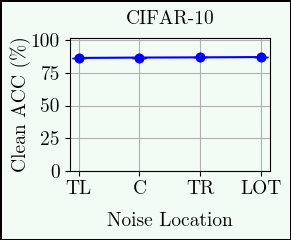

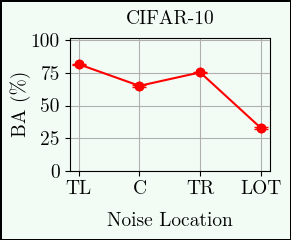

In [54]:
# Plot Clean Accuracy (blue line)
plot_line_by_location(d, 'clean_acc', 'Clean ACC (%)', 'blue', intensities[0])

# Plot Attack Success Rate (red line)
plot_line_by_location(d, 'asr', 'BA (%)', 'red', intensities[0])

## Conclusion after train: Not much diff

# Test: Skip. No logically correct way to split data based on noise.